---
---

#  Application Project - SingularIT
---
---

# Context
---

- Explaining the Project
- hypothesis final......


# Imports & Settings
---

In [30]:
import pandas as pd
import numpy as np
import json
import glob
import os
import matplotlib.pyplot as plt

# Task - Data
---

In [17]:
folder_path = 'results' #data folder
file_pattern = os.path.join(folder_path, '*.json') #specifying json data format
json_files = glob.glob(file_pattern) 

all_dataframes = []

for file in json_files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)

        df_temp = pd.json_normalize(
            data['runs'], 
            record_path=['events'], 
            meta=['run_id', 'player_1', 'player_2']
        )

        df_temp['source_file'] = os.path.basename(file)
            
        all_dataframes.append(df_temp)
            
timestamped_data = pd.concat(all_dataframes, ignore_index=True)

In [18]:
timestamped_data

,timestamp,player,type,bar,side,successful,run_id,player_1,player_2,source_file
0,2.985530,Diana,contact,Middle1,Middle,NaN,0,Diana,Hans,Diana-Hans.json
1,3.749828,Diana,contact,Attack1,Right,NaN,0,Diana,Hans,Diana-Hans.json
2,6.102422,Hans,contact,Attack2,Middle,NaN,0,Diana,Hans,Diana-Hans.json
3,10.453081,Hans,shot,NaN,NaN,True,0,Diana,Hans,Diana-Hans.json
4,20.291921,Diana,contact,Middle1,Middle,NaN,0,Diana,Hans,Diana-Hans.json
...,...,...,...,...,...,...,...,...,...,...
29332,910.737441,Tanja,contact,Defense2,Middle,NaN,4,Simon,Tanja,Simon-Tanja.json
29333,911.646976,Tanja,shot,NaN,NaN,False,4,Simon,Tanja,Simon-Tanja.json
29334,911.837511,Simon,contact,Goal1,Middle,NaN,4,Simon,Tanja,Simon-Tanja.json
29335,913.151401,Simon,contact,Defense1,Left,NaN,4,Simon,Tanja,Simon-Tanja.json


In [19]:
timestamped_data.shape

(29337, 10)

In [20]:
def create_results_table(df):
    is_shot = (df['type'] == 'shot')
    is_goal = (df['successful'] == True)
    
    df['is_p1_goal'] = is_shot & is_goal & (df['player'] == df['player_1'])
    df['is_p2_goal'] = is_shot & is_goal & (df['player'] == df['player_2'])

    results = df.groupby(['source_file', 'run_id']).agg({
        'player_1': 'first',
        'player_2': 'first',
        'is_p1_goal': 'sum',
        'is_p2_goal': 'sum'
    }).reset_index()

    results = results.rename(columns={
        'is_p1_goal': 'points_player_1',
        'is_p2_goal': 'points_player_2'
    })

    results['winner'] = np.where(
        results['points_player_2'] > results['points_player_1'], results['player_2'], results['player_1'])
    
    results['loser'] = np.where(
        results['points_player_2'] > results['points_player_1'], results['player_1'], results['player_2'])

    df.drop(columns=['is_p1_goal', 'is_p2_goal'], inplace=True)

    return results

results_table = create_results_table(timestamped_data)

results_table

,source_file,run_id,player_1,player_2,points_player_1,points_player_2,winner,loser
0,Diana-Hans.json,0,Diana,Hans,10,5,Diana,Hans
1,Diana-Hans.json,1,Diana,Hans,10,5,Diana,Hans
2,Diana-Hans.json,2,Diana,Hans,10,5,Diana,Hans
3,Diana-Hans.json,3,Diana,Hans,10,4,Diana,Hans
4,Diana-Hans.json,4,Diana,Hans,10,5,Diana,Hans
...,...,...,...,...,...,...,...,...
70,Simon-Tanja.json,0,Simon,Tanja,10,8,Simon,Tanja
71,Simon-Tanja.json,1,Simon,Tanja,9,10,Tanja,Simon
72,Simon-Tanja.json,2,Simon,Tanja,5,10,Tanja,Simon
73,Simon-Tanja.json,3,Simon,Tanja,10,6,Simon,Tanja


In [21]:
results_table['winner'].value_counts().reset_index()

,winner,count
0,Diana,22
1,Simon,17
2,Olga,15
3,Magnus,10
4,Tanja,8
5,Hans,3


In [22]:
def create_win_matrix(df):
    players = sorted(pd.unique(df[['player_1','player_2']].to_numpy().ravel()))

    win_matrix = (
        pd.crosstab(df.winner, df.loser)
        .reindex(index=players, columns=players, fill_value=0)
        .astype(float)
    )
    win_matrix.where(~np.eye(len(players), dtype=bool), np.nan, inplace=True)
    return win_matrix

win_matrix = create_win_matrix(results_table)
win_matrix

loser,Diana,Hans,Magnus,Olga,Simon,Tanja
winner,,,,,,
Diana,NaN,5.0,4.0,5.0,3.0,5.0
Hans,0.0,NaN,0.0,1.0,0.0,2.0
Magnus,1.0,5.0,NaN,1.0,1.0,2.0
Olga,0.0,4.0,4.0,NaN,2.0,5.0
Simon,2.0,5.0,4.0,3.0,NaN,3.0
Tanja,0.0,3.0,3.0,0.0,2.0,NaN


# Rutvik and Cosima

In [23]:
timestamped_data['is_goal'] = (timestamped_data['type'] == 'shot') & (timestamped_data['successful'] == True)

timestamped_data['round'] = 0

for (source_file, run_id), group in timestamped_data.groupby(['source_file', 'run_id']):
    current_round = 1
    rounds = []

    for is_goal in group['is_goal'].shift(fill_value=False):
        if is_goal:
            current_round += 1
        rounds.append(current_round)

    timestamped_data.loc[group.index, 'round'] = rounds

def aggregate_rounds(group):
    p1 = group['player_1'].iloc[0]
    p2 = group['player_2'].iloc[0]

    goal_rows = group.loc[group['is_goal']]
    round_winner = goal_rows['player'].iloc[0] if not goal_rows.empty else None

    start_ts = group['timestamp'].iloc[0]
    end_ts = group['timestamp'].iloc[-1]
    duration = group['timestamp'].iloc[-1] - group['timestamp'].iloc[0]

    contacts_player1 = len(group[(group['player'] == p1) & (group['type'] == 'contact')])
    contacts_player2 = len(group[(group['player'] == p2) & (group['type'] == 'contact')])

    shots_player1 = len(group[(group['player'] == p1) & (group['type'] == 'shot')])
    shots_player2 = len(group[(group['player'] == p2) & (group['type'] == 'shot')])

    return pd.Series({
        'player_1': p1,
        'player_2': p2,
        'round_winner': round_winner,
        'start': start_ts,
        'end': end_ts,
        'duration': duration,
        'contacts_player1': contacts_player1,
        'contacts_player2': contacts_player2,
        'shots_player1': shots_player1,
        'shots_player2': shots_player2,
    })

round_data = (
    timestamped_data
    .groupby(['source_file', 'run_id', 'round'], as_index=False)
    .apply(aggregate_rounds)
    .reset_index(drop=True)
)


In [9]:
#adding the points each player has (after this round)
def compute_scores(group):
    group = group.copy()
    group['points_player1'] = (group['round_winner'] == group['player_1']).cumsum()
    group['points_player2'] = (group['round_winner'] == group['player_2']).cumsum()
    return group

round_data = round_data.groupby(['source_file', 'run_id'], group_keys=False).apply(compute_scores)

In [24]:
round_data

,source_file,run_id,round,player_1,player_2,round_winner,start,end,duration,contacts_player1,contacts_player2,shots_player1,shots_player2
0,Diana-Hans.json,0,1,Diana,Hans,Hans,2.985530,10.453081,7.467551,2,1,0,1
1,Diana-Hans.json,0,2,Diana,Hans,Diana,20.291921,51.365341,31.073420,5,5,3,2
2,Diana-Hans.json,0,3,Diana,Hans,Diana,56.560030,150.898025,94.337994,15,17,5,7
3,Diana-Hans.json,0,4,Diana,Hans,Diana,164.168779,178.463446,14.294667,3,2,3,1
4,Diana-Hans.json,0,5,Diana,Hans,Hans,191.487753,208.643816,17.156064,4,5,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1214,Simon-Tanja.json,4,11,Simon,Tanja,Tanja,608.090735,738.918799,130.828064,22,19,9,5
1215,Simon-Tanja.json,4,12,Simon,Tanja,Simon,743.100045,786.364901,43.264856,10,4,2,1
1216,Simon-Tanja.json,4,13,Simon,Tanja,Simon,790.162325,844.426036,54.263711,13,6,5,3
1217,Simon-Tanja.json,4,14,Simon,Tanja,Simon,848.255402,898.807072,50.551670,7,8,2,4


## Basic EDA - Shot Conversion? To understand player traits better?

In [ ]:
# Conversion rate is number of successful goals / shot.
timestamped_data['is_a_shot'] = timestamped_data['type'] == 'shot'

player_conversion_rate = timestamped_data.groupby('player').agg(shots=('is_a_shot','sum'), goals=('is_goal', 'sum')).reset_index()
player_conversion_rate['conversion_rate'] = (player_conversion_rate['goals'] / player_conversion_rate['shots'])


In [36]:
player_conversion_rate

,player,shots,goals,conversion_rate
0,Diana,944,240,0.254237
1,Hans,1247,162,0.129912
2,Magnus,1002,186,0.185629
3,Olga,664,223,0.335843
4,Simon,1368,219,0.160088
5,Tanja,1141,189,0.165644


Text(0.5, 1.0, 'Shot Conversion Rate for each player')

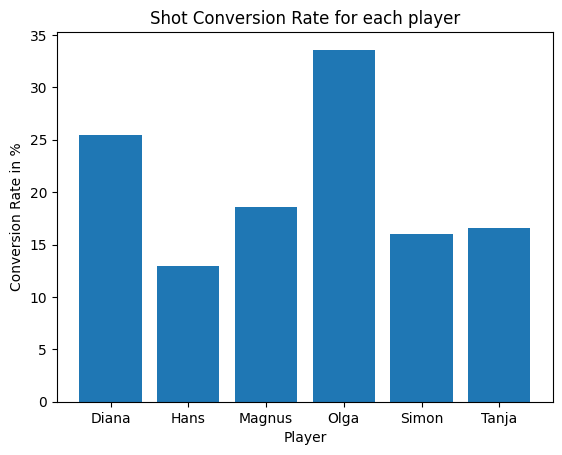

In [39]:
plt.figure()
plt.xlabel('Player')
plt.ylabel('Conversion Rate in %')
plt.bar(player_conversion_rate['player'], (player_conversion_rate['conversion_rate'] * 100))
plt.title('Shot Conversion Rate for each player')

## Advance EDA

# Natesh and Harshitha

In [11]:
# Look for all ".json" files
results = glob.glob("results/*.json")
results

['results\\Diana-Hans.json',
 'results\\Diana-Magnus.json',
 'results\\Diana-Olga.json',
 'results\\Diana-Simon.json',
 'results\\Diana-Tanja.json',
 'results\\Hans-Magnus.json',
 'results\\Hans-Olga.json',
 'results\\Hans-Simon.json',
 'results\\Hans-Tanja.json',
 'results\\Magnus-Olga.json',
 'results\\Magnus-Simon.json',
 'results\\Magnus-Tanja.json',
 'results\\Olga-Simon.json',
 'results\\Olga-Tanja.json',
 'results\\Simon-Tanja.json']

In [12]:
list = []

for files in results:
    # Open files
    with open(files, "r") as file:
        data = json.load(file)

    events_list = []
    # Assign filename to "game" column
    game = os.path.basename(files).replace(".json", "")

    # Loop through the runs
    for run in data.get("runs", []):
        run_id = run["run_id"]
        player_1 = run["player_1"]
        player_2 = run["player_2"]
        # Loop through events
        for event in run.get("events", []):
            events_list.append({
                "game": game,
                "run_id": run_id,
                "player_1": player_1,
                "player_2": player_2,
                "timestamp": event["timestamp"],
                "player": event["player"],
                "event_type": event["type"],
                "bar": event.get("bar", pd.NA),
                "side": event.get("side", pd.NA),
                "is_goal": event.get("successful", pd.NA)
            })

    # Convert to dataframe
    df_game = pd.DataFrame(events_list)
    list.append(df_game)

In [13]:
# Combine dataframes
df = pd.concat(list, ignore_index=True)
print("Dataframe size:", len(df))
df.head()

Dataframe size: 29337


,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal
0,Diana-Hans,0,Diana,Hans,2.985530,Diana,contact,Middle1,Middle,<NA>
1,Diana-Hans,0,Diana,Hans,3.749828,Diana,contact,Attack1,Right,<NA>
2,Diana-Hans,0,Diana,Hans,6.102422,Hans,contact,Attack2,Middle,<NA>
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,NaN,NaN,True
4,Diana-Hans,0,Diana,Hans,20.291921,Diana,contact,Middle1,Middle,<NA>


In [14]:
# Sorting by matchup, run and timestamp
df = df.sort_values(by=["game", "run_id", "timestamp"]).reset_index(drop=True)
df.head()

,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal
0,Diana-Hans,0,Diana,Hans,2.985530,Diana,contact,Middle1,Middle,<NA>
1,Diana-Hans,0,Diana,Hans,3.749828,Diana,contact,Attack1,Right,<NA>
2,Diana-Hans,0,Diana,Hans,6.102422,Hans,contact,Attack2,Middle,<NA>
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,NaN,NaN,True
4,Diana-Hans,0,Diana,Hans,20.291921,Diana,contact,Middle1,Middle,<NA>


In [15]:
# Sort by matchup, run and timestamp
df = df.sort_values(by=["game", "run_id", "timestamp"]).reset_index(drop=True)
df.head()

,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal
0,Diana-Hans,0,Diana,Hans,2.985530,Diana,contact,Middle1,Middle,<NA>
1,Diana-Hans,0,Diana,Hans,3.749828,Diana,contact,Attack1,Right,<NA>
2,Diana-Hans,0,Diana,Hans,6.102422,Hans,contact,Attack2,Middle,<NA>
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,NaN,NaN,True
4,Diana-Hans,0,Diana,Hans,20.291921,Diana,contact,Middle1,Middle,<NA>


In [16]:
# Replacing all null values to "False"
df["is_goal"] = df["is_goal"].fillna(False)
df.head()

,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal
0,Diana-Hans,0,Diana,Hans,2.985530,Diana,contact,Middle1,Middle,False
1,Diana-Hans,0,Diana,Hans,3.749828,Diana,contact,Attack1,Right,False
2,Diana-Hans,0,Diana,Hans,6.102422,Hans,contact,Attack2,Middle,False
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,NaN,NaN,True
4,Diana-Hans,0,Diana,Hans,20.291921,Diana,contact,Middle1,Middle,False


In [17]:
# Assigning correct data types
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df["run_id"] = pd.to_numeric(df["run_id"], errors="coerce")
df["is_goal"] = df["is_goal"].astype(bool)
df.head()

,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal
0,Diana-Hans,0,Diana,Hans,2.985530,Diana,contact,Middle1,Middle,False
1,Diana-Hans,0,Diana,Hans,3.749828,Diana,contact,Attack1,Right,False
2,Diana-Hans,0,Diana,Hans,6.102422,Hans,contact,Attack2,Middle,False
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,NaN,NaN,True
4,Diana-Hans,0,Diana,Hans,20.291921,Diana,contact,Middle1,Middle,False


In [18]:
# Create a new column "is_shot"
df["is_shot"] = df["event_type"] == "shot"

In [19]:
# Fill missing values for bar/side with "Unknown" 
df["bar"] = df["bar"].fillna("Unknown")
df["side"] = df["side"].fillna("Unknown")

In [20]:
print(df["event_type"].value_counts())
print(df["player"].value_counts())

event_type
contact    22971
shot        6366
Name: count, dtype: int64
player
Olga      5969
Magnus    5230
Tanja     5100
Simon     5084
Hans      4051
Diana     3903
Name: count, dtype: int64


In [21]:
# Check results
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (29337, 11)


,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal,is_shot
0,Diana-Hans,0,Diana,Hans,2.985530,Diana,contact,Middle1,Middle,False,False
1,Diana-Hans,0,Diana,Hans,3.749828,Diana,contact,Attack1,Right,False,False
2,Diana-Hans,0,Diana,Hans,6.102422,Hans,contact,Attack2,Middle,False,False
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,Unknown,Unknown,True,True
4,Diana-Hans,0,Diana,Hans,20.291921,Diana,contact,Middle1,Middle,False,False


In [22]:
# Summary
summary = df.groupby(["player", "event_type"]).size().unstack()

summary = summary.fillna(0)

shots = df[df["event_type"] == "shot"]

success = shots.groupby("player")["is_goal"].sum()

summary["is_goal"] = success
summary["rate"] = summary["is_goal"] / summary["shot"]

summary = summary.fillna(0)

summary

event_type,contact,shot,is_goal,rate
player,,,,
Diana,2959,944,240,0.254237
Hans,2804,1247,162,0.129912
Magnus,4228,1002,186,0.185629
Olga,5305,664,223,0.335843
Simon,3716,1368,219,0.160088
Tanja,3959,1141,189,0.165644


In [23]:
# Side statistics
side_counts = df.groupby(["player", "side"]).size().unstack()
side_counts = side_counts.fillna(0)
side_percent = side_counts.div(side_counts.sum(axis=1), axis=0)
side_percent

side,Left,Middle,Right,Unknown
player,,,,
Diana,0.284909,0.331284,0.141942,0.241865
Hans,0.189089,0.327573,0.175512,0.307825
Magnus,0.230402,0.368069,0.209943,0.191587
Olga,0.261853,0.390518,0.236388,0.111241
Simon,0.214792,0.318057,0.198072,0.269079
Tanja,0.215098,0.347647,0.213529,0.223725


In [24]:
# Success rate
shots = df[df["event_type"] == "shot"]

result = shots.groupby("player")["is_goal"].value_counts().unstack().fillna(0)

result["success_rate"] = result[True] / (result[True] + result[False])

result

is_goal,False,True,success_rate
player,,,
Diana,704,240,0.254237
Hans,1085,162,0.129912
Magnus,816,186,0.185629
Olga,441,223,0.335843
Simon,1149,219,0.160088
Tanja,952,189,0.165644
